# Resolution-Limited Control

Minimal simulation demonstrating that increasing control effort
may degrade effective observability and increase tracking error.

This notebook explores a simple dynamical model illustrating
a possible control–resolution trade-off.

## Concept

In many real systems stronger control improves performance only
up to a certain point.

Beyond some control intensity the system may become dominated by
noise, turbulence, or limited observability.

This notebook demonstrates a minimal mechanism where:

**control effort → resolution degradation → higher measurement noise**

The result is a finite limit on achievable control precision.

## Minimal Model

**State dynamics**

$$\dot{x} = -k x + u$$

**Resolution dynamics**

$$\dot{\ell} = \alpha |u| - (\ell - \ell_0)/\tau_\ell$$

**Observation**

$$y = x + \eta(\ell), \quad \eta(\ell) \sim \mathcal{N}(0, \sigma^2(\ell)), \quad \sigma(\ell) = \sigma_0 + \beta \ell$$

**Control**

$$u = \mathrm{clip}(K(r - y))$$

Stronger control increases $\ell$, which increases measurement noise.

## Model Parameters

To demonstrate the qualitative behavior of the system we choose a simple set of parameters.

### System dynamics

- **k** — natural relaxation rate of the system state  
  Controls how quickly the state returns to equilibrium in the absence of control.

### Resolution dynamics

- **ℓ₀** — baseline resolution scale  
  Represents the minimal distinguishable scale of the system when no control effort is applied.

- **α** — control–resolution coupling coefficient  
  Determines how strongly control effort increases the resolution scale.

- **τℓ** — resolution relaxation time  
  Describes how quickly the resolution scale returns to its baseline value after strong control actions.

### Observation noise

- **σ₀** — baseline measurement noise  
  Represents the intrinsic noise level of the measurement process.

- **β** — resolution noise amplification factor  
  Determines how strongly measurement noise increases when the resolution scale grows.

### Control parameters

- **K** — proportional control gain  
  Determines how aggressively the controller reacts to the observed error.

- **r** — target system state.

### Simulation parameters

- **dt** — integration timestep  
- **T** — total simulation time

These parameters are not intended to represent a specific physical system.  
They are chosen only to illustrate the qualitative effect of **resolution degradation under strong control effort**.

## Parameter values used in the simulation

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Base system
k = 1.0
l0 = 0.1
r = 1.0

# Resolution / noise settings
tau_l = 8
u_max = 2.5
sigma0 = 0.04

# Simulation settings
dt = 0.01
T = 30.0

# Sweep settings
alpha_values = [0.15, 0.3, 0.6]
beta_values = [0.4, 0.8, 1.2]
K_grid = np.linspace(0.1, 12.0, 60)

## Simulation model

In [7]:
def simulate(K, alpha, beta, seed=42):
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt) + 1
    t = np.linspace(0.0, T, n_steps)
    x = np.zeros(n_steps)
    ell = np.zeros(n_steps)
    y = np.zeros(n_steps)
    u = np.zeros(n_steps)
    err = np.zeros(n_steps)
    sigma = np.zeros(n_steps)
    x[0] = 0.0
    ell[0] = l0
    for i in range(n_steps - 1):
        sigma[i] = sigma0 + beta * ell[i]
        y[i] = x[i] + rng.normal(0.0, sigma[i])
        u_raw = K * (r - y[i])
        u[i] = np.clip(u_raw, -u_max, u_max)
        err[i] = r - x[i]
        x_dot = -k * x[i] + u[i]
        x[i + 1] = x[i] + dt * x_dot
        ell_dot = alpha * abs(u[i]) - (ell[i] - l0) / tau_l
        ell[i + 1] = max(0.0, ell[i] + dt * ell_dot)
    sigma[-1] = sigma0 + beta * ell[-1]
    y[-1] = x[-1] + rng.normal(0.0, sigma[-1])
    u[-1] = np.clip(K * (r - y[-1]), -u_max, u_max)
    err[-1] = r - x[-1]
    return {"t": t, "x": x, "ell": ell, "y": y, "u": u, "err": err, "sigma": sigma}


def evaluate_gain(K, alpha, beta, n_runs=50, t_warmup=10.0):
    warmup_idx = int(t_warmup / dt)
    mean_abs_error_runs = []
    for seed in range(n_runs):
        res = simulate(K, alpha, beta, seed=seed)
        mean_abs_error_runs.append(np.mean(np.abs(res["err"][warmup_idx:])))
    return {
        "K": K,
        "mean_abs_error": np.mean(mean_abs_error_runs),
    }


def plot_trajectories(results_by_k, r):
    # Plot x(t), ℓ(t), |error| for several gains.
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for K, res in results_by_k.items():
        axes[0].plot(res["t"], res["x"], label=f"K={K}")
        axes[1].plot(res["t"], res["ell"], label=f"K={K}")
        axes[2].plot(res["t"], np.abs(res["err"]), label=f"K={K}")
    axes[0].axhline(r, linestyle="--", color="black", label="target r")
    axes[0].set_ylabel("state x(t)")
    axes[0].set_title("Example trajectories: weak / medium / aggressive control")
    axes[0].legend()
    axes[1].set_ylabel("resolution ℓ(t)")
    axes[1].legend()
    axes[2].set_ylabel("|error|")
    axes[2].set_xlabel("time")
    axes[2].legend()
    plt.tight_layout()
    plt.show()


def plot_sweep(alpha_values, beta_values, K_grid):
    # Sensitivity map: mean tracking error vs K for each (α, β).
    fig, axes = plt.subplots(len(alpha_values), len(beta_values), figsize=(12, 8), sharex=True, sharey=True)
    for i, a in enumerate(alpha_values):
        for j, b in enumerate(beta_values):
            errors = [evaluate_gain(K, a, b, n_runs=30)["mean_abs_error"] for K in K_grid]
            axes[i, j].plot(K_grid, errors)
            axes[i, j].set_title(f"α={a}, β={b}")
            axes[i, j].grid(True, alpha=0.35)
    for j in range(len(beta_values)):
        axes[-1, j].set_xlabel("control gain K")
    for i in range(len(alpha_values)):
        axes[i, 0].set_ylabel("mean tracking error")
    plt.tight_layout()
    plt.show()


## Example trajectories

We first compare a few controller gains in the time domain.

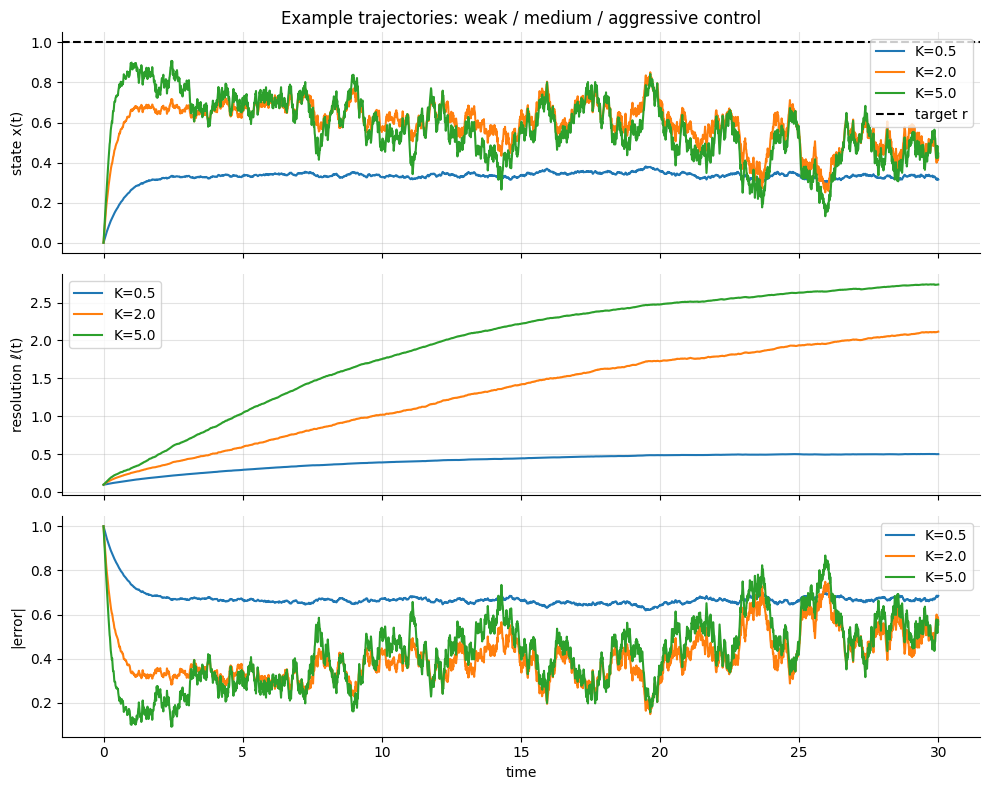

In [8]:
# One representative (α, β) for trajectory comparison
alpha_demo = 0.15
beta_demo = 0.8
K_values_demo = [0.5, 2.0, 5.0]

results_by_k = {
    K: simulate(K, alpha_demo, beta_demo, seed=42)
    for K in K_values_demo
}
plot_trajectories(results_by_k, r)

## Control gain sweep

We vary controller gain $K$ and measure the resulting tracking error
for different resolution-coupling parameters.

**Parameter meaning:**

- **α** — how strongly control effort increases the resolution scale
- **β** — how strongly resolution loss increases measurement noise

Tracking error is averaged after an initial transient period,
so the metric reflects steady-state control performance rather than startup behavior.

## Representative control-precision limit

The following parameter set illustrates the main effect of the model:
tracking error decreases with control gain only up to a finite optimum.
Beyond this point stronger control increases error due to resolution degradation.

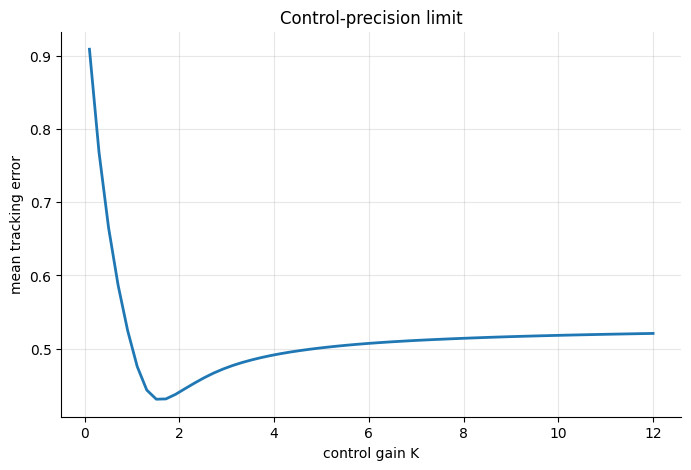

In [9]:
alpha = 0.15
beta = 0.8

metrics = [evaluate_gain(K, alpha=alpha, beta=beta, n_runs=50) for K in K_grid]

K_plot = np.array([m["K"] for m in metrics])
err_plot = np.array([m["mean_abs_error"] for m in metrics])

plt.figure(figsize=(8, 5))
plt.plot(K_plot, err_plot, linewidth=2)
plt.xlabel("control gain K")
plt.ylabel("mean tracking error")
plt.title("Control-precision limit")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:**

For small controller gains the system is under-actuated and tracking error is large.

Increasing gain improves tracking until resolution degradation begins to dominate.

Beyond this point the controller increasingly reacts to noise rather than the true state.

The matrix below shows how the effect depends on α and β (sensitivity map).

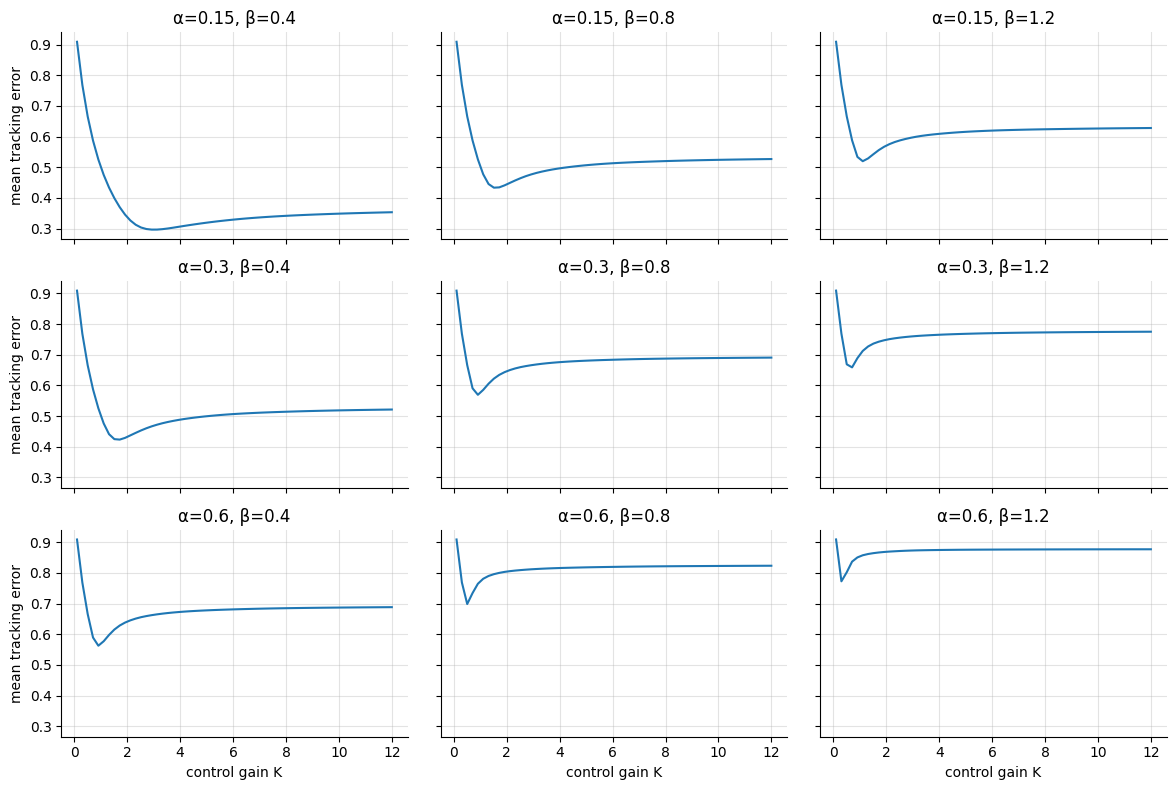

In [5]:
plot_sweep(alpha_values, beta_values, K_grid)

## Key takeaway

The simulation shows that increasing controller gain improves tracking
only up to a finite optimum.

Beyond that point, stronger control increases effective resolution loss,
amplifies noise, and degrades tracking performance.

This illustrates a possible **control-induced precision limit**
in systems where actuation degrades observability.

## Summary

This notebook demonstrates a minimal mechanism by which control effort
can degrade effective observability.

**Main ingredients:**
- bounded control
- dynamic resolution scale
- resolution-dependent measurement noise

**Main result:**
- tracking improves only up to a finite control intensity
- beyond that point, stronger control can increase error